# Comparing Models to Observations

Now that you are familiar with how to use picaso to generate spectra and interrogate spectral features, it's time to start comparing them to observations! We'll start with one of the simplest approaches: **grid model $\chi^2$ fits** and apply it to the two classes of object Roman-CGI will observe.

- For [**reflected-light**](#RL) targets, we'll use the Batalha+2018 model grid to generate some mock Roman-CGI observations and conduct a grid search to see how well we can recover the true parameters.

- For [**self-luminous**](#SL) targets, we'll use the Sonora-Bobcat model grid and existing infrared observations to investigate the degree to which adding Roman-CGI observations helps constrain target properties.

NOTE: These procedures are simplified from what would need to be done for real observations in the interest of time. As you work through them, take note of how you might want to make adjustments for working with real observations... you might come up with some fruitful directions for your group project! The supplementary quickstart guides are also meant to help you move towards a more comprehensive, realistic data analysis.

----------------------------
## <a id="RL"></a>Reflected light target: generating mock Roman-CGI observations and doing a grid-search with Batalha+2018 models

The grid from Batalha et al. 2018 provides 1D radiative-convective equilibrium T-P profiles for planets irradiated by a solar-type star, pre-computed with condensate cloud models. It assumes T_int is fixed to 150 K and that the surface gravity is 25 m^2/s, similar to Jupiter while varying three parameters: metallicity, planet-star separation, and *f*<sub>sed</sub>.

We will:
1. Pick a "true" planet and compute its noiseless Roman-CGI spectrum
2. Add simple random noise to simulate observations, NOTE: a more realistic approach would use corgi-etc or extract spectra and associated errors from corgi-sim 
3. Construct a 3d grid of [M/H], *d*, and *f*<sub>sed</sub> (for each model: compute spectra, bin to Roman-CGI observations)
4. Loop through the grid and compute $\chi^2$
5. Analyze quality of results-- how well can you recover the true parameters? what are the degeneracies in this parameter space?

First we have to do our package imports, and the usual setting PICASO reference data path

In [1]:
%matplotlib inline
%config InlineBackend.figure_format='retina'

import os, warnings
warnings.filterwarnings('ignore')
# ── SET YOUR PATHS HERE ──────────────────────────────────────────
PICASO_REFDATA = '/Users/briannalacy/Research/Picaso_Tutorial_Dev/picaso/reference'
PYSYN_CDBS = '/Users/briannalacy/Research/Picaso_Tutorial_Dev/picaso/reference/stellar_grids'
# ─────────────────────────────────────────────────────────────────
os.environ['picaso_refdata'] = PICASO_REFDATA
os.environ['PYSYN_CDBS'] = PYSYN_CDBS

from picaso import justdoit as jdi
from virga import justdoit as vj   # for recommend_gas

import glob
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
import pandas as pd
import astropy.units as u
from tqdm.auto import tqdm

import sys
sys.path.insert(0, '.') # this will help make sure we find roman_tutorial_utils
import roman_tutorial_utils as rtu

The locations of resources we'll need later...

In [2]:
sonora_db = os.path.join(os.getenv('picaso_refdata'), 'sonora_grids', 'bobcat')
virga_dir = os.path.join(os.getenv('picaso_refdata'), 'virga')
opacity_db = os.path.join(os.getenv('picaso_refdata'),'opacities', 'opacities_0.3_15_R15000.db')

Now we load in our opacities

In [3]:
# Optical opacity connection: covers Roman-CGI Bands 1, 3, 4 (0.5–1.0 µm)
opa_opt = jdi.opannection(wave_range=[0.5, 1.0],filename_db=opacity_db)
print("Optical opannection ready:", opa_opt.nwno, "wavenumber points")
print("molecules loaded are:", opa_opt.molecules)

Optical opannection ready: 10397 wavenumber points
molecules loaded are: ['C2H2' 'CH4' 'CO' 'CO2' 'H2O' 'H2S' 'K' 'Na' 'OCS' 'SO2']


### Steps 1+2: Generate the "True" Spectrum and Mock Roman-CGI Observations

We pick a specific Batalha+2018 grid point as our synthetic planet, compute its reflected-light spectrum with PICASO, then sample it at the Roman-CGI band passes and add Gaussian noise.

Host star: Teff=5000.0 K, logg=4.0
Planet:    Mp=1.0 M_Jup, Rp=1.0 R_Jup, phase=0.0 radians
Truth: [M/H]=1.0, d=1.0 AU, fsed=1
Mock data: 11 points  (1 B1 photometric + 9 B3 channels + 1 B4 photometric)


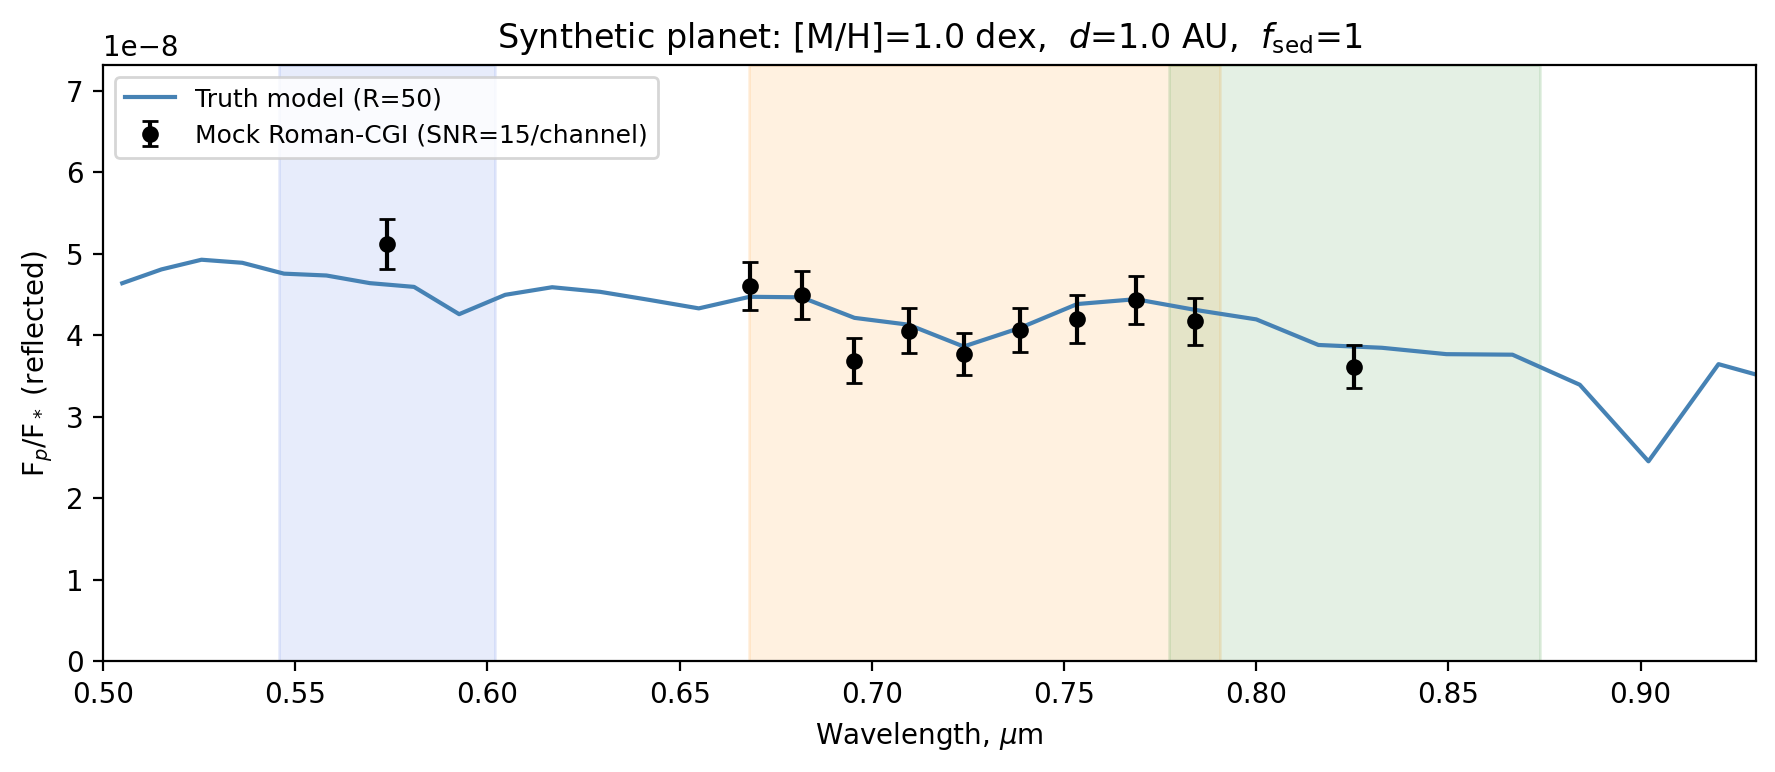

In [4]:
# ── Fixed physical parameters ────────────────────────────────────────────────
STELLAR_TEFF = 5000.0  # K   — solar analogue host star
STELLAR_LOGG = 4.0     # log g cgs
STELLAR_MH   = 0.0     # [Fe/H] dex

PLANET_MASS  = 1.0     # M_Jupiter 
PLANET_RP    = 1.0     # R_Jupiter
PHASE_RAD    = 0.0     # radians — we'll do full phase for speed

print(f"Host star: Teff={STELLAR_TEFF} K, logg={STELLAR_LOGG}")
print(f"Planet:    Mp={PLANET_MASS} M_Jup, Rp={PLANET_RP} R_Jup, phase={PHASE_RAD} radians")

# ── True planet parameters ───────────────────────────────────────────────────
TRUE_MH   = 1.0   # [M/H] dex — metal-enriched atmosphere
TRUE_SEP  = 1.0   # AU        — inner warm Jupiter
TRUE_FSED = 1     # moderate sedimentation efficiency

#Load atmosphere profile + cloud profile DataFrames for the truth model
#(includes recalculation of chemistry based on thermochemical equilibrium)
pt_true, cld_true = rtu.read_batalha_profile(TRUE_MH, TRUE_SEP, TRUE_FSED)

#Set up a reflected-light PICASO calculation
inputs_true = jdi.inputs()
inputs_true.phase_angle(PHASE_RAD)
inputs_true.gravity(mass=PLANET_MASS, mass_unit=u.Unit('M_jup'),
                    radius=PLANET_RP, radius_unit=u.Unit('R_jup'))
inputs_true.star(opa_opt, STELLAR_TEFF, STELLAR_MH, STELLAR_LOGG,
                 radius=1.0, radius_unit=u.Unit('R_sun'),
                 semi_major=TRUE_SEP, semi_major_unit=u.Unit('au'))
inputs_true.atmosphere(df=pt_true)
inputs_true.clouds(df=cld_true)

#Calculate the "true" reflected-light spectrum in just the optical
spec_true = inputs_true.spectrum(opa_opt, calculation='reflected', full_output=True)

#Extract Roman-CGI band fluxes from the noiseless model
b1_true, b3_true, b4_true = rtu.mimic_roman_cgi_obs(spec_true, 
                                                    spec_key='fpfs_reflected') #we'll work in planet-star flux ratio space

#Pack all three bands into flat arrays: [B1 photometric] + [B3 spectroscopic channels] + [B4 photometric]
wl_mock  = np.concatenate([[b1_true[0]], b3_true[0], [b4_true[0]]])
fpfs_truth = np.concatenate([[b1_true[1]], b3_true[1], [b4_true[1]]])
N_MOCK   = len(wl_mock)

#Add Gaussian noise at SNR = 15 per channel <------- this is much too simplistic!
SNR = 15.0
np.random.seed(3)  # this helps with reproducibility, 
                   # you can try starting with a few different seeds to see how much
                   # data can change within SNR = 15
fpfs_err = fpfs_truth / SNR
fpfs_obs = fpfs_truth + np.random.normal(0, fpfs_err)

print(f"Truth: [M/H]={TRUE_MH}, d={TRUE_SEP} AU, fsed={TRUE_FSED}")
print(f"Mock data: {N_MOCK} points  "
      f"(1 B1 photometric + {len(b3_true[0])} B3 channels + 1 B4 photometric)")

#Plot the noiseless true spectrum and the simulated Roman-CGI observations
#as a sanity check
fig, ax = plt.subplots(figsize=(9, 4))

wno_r50, fpfs_r50 = jdi.mean_regrid(spec_true['wavenumber'],
                                     spec_true['fpfs_reflected'], R=50)
ax.plot(1e4 / wno_r50, fpfs_r50, color='steelblue', lw=1.5,
        label='Truth model (R=50)')

ax.errorbar(wl_mock, fpfs_obs, yerr=fpfs_err,
            fmt='o', color='k', ms=5, elinewidth=1.5, capsize=3,
            label=f'Mock Roman-CGI (SNR={SNR:.0f}/channel)', zorder=5)

ymax = max(fpfs_r50.max(), (fpfs_obs + fpfs_err).max()) * 1.35
rtu.format_roman_cgi_spectrum(ax, 0, ymax,
                              ylabel='F$_p$/F$_*$ (reflected)', xlim=(0.50, 0.93))
ax.legend(fontsize=9)
ax.set_title(f'Synthetic planet: [M/H]={TRUE_MH} dex,  $d$={TRUE_SEP} AU,  '
             f'$f_{{\\rm sed}}$={TRUE_FSED}')
plt.tight_layout()
plt.show()

> Looks good!
>
> Note that we are being quite optimistic here... actual Roman-CGI observations will probably have only a subset of the bands, and likely lower SNR. For band 3 spectra there could also be some correlated noise.

### Step 3: Construct the model grid

We will consider a 3D grid of Batalha+2018 models:  

\[M/H] ∈ {0.0, 0.5, 1.0, 1.5} dex × *d* ∈ {0.7, 1.0, 1.5, 2.0, 3.0} AU × $f_{\mathrm{sed}}$ ∈ {0.03, 0.1, 1, 3, 6}   → **100 models** total. 

For each grid point we:

1. Load the pre-computed T-P and cloud profiles with `read_batalha_profile`
2. Run a PICASO reflected-light calculation
3. Sample the model spectrum in the Roman-CGI bandpasses

**Runtime:** ~5-10 minutes 

In [5]:
# ── Grid definition ──────────────────────────────────────────────────────────
MH_GRID   = [0.0, 0.5, 1.0, 1.5]      # [M/H] dex
SEP_GRID  = [0.7, 1.0, 1.5, 2.0, 3.0] # orbital separation (AU)
FSED_GRID = [0.03, 0.1, 1, 3,6]       # sedimentation efficiency

dims   = (len(MH_GRID), len(SEP_GRID), len(FSED_GRID))
n_pts  = N_MOCK

#prep some storage space for the loop to fill: model fluxes at the same Roman-CGI wavelengths as mock data
grid_models = np.full((*dims, n_pts), np.nan)

print(f"Grid: {len(MH_GRID)} [M/H] × {len(SEP_GRID)} sep × {len(FSED_GRID)} fsed "
      f"= {int(np.prod(dims))} models\n")

#now time to actually fill the grid in
#this outer layer provides us a nice progress bar
with tqdm(total=int(np.prod(dims)), desc='Batalha+2018 reflected-light grid') as pbar: 
    # here is our nested for loop over the grid
    for i, mh in enumerate(MH_GRID):
        for j, sep in enumerate(SEP_GRID):
            for k, fsed in enumerate(FSED_GRID):
                try:
                    # Load T-P + cloud profile 
                    pt_df, cld_df = rtu.read_batalha_profile(mh, sep, fsed)
    
                    # PICASO reflected-light calculation
                    case = jdi.inputs()
                    case.phase_angle(PHASE_RAD)
                    case.gravity(mass=PLANET_MASS, mass_unit=u.Unit('M_jup'),
                                 radius=PLANET_RP, radius_unit=u.Unit('R_jup'))
                    # Note: semi_major=sep 
                    case.star(opa_opt, STELLAR_TEFF, STELLAR_MH, STELLAR_LOGG,
                              radius=1.0, radius_unit=u.Unit('R_sun'),
                              semi_major=sep, semi_major_unit=u.Unit('au'))
                    case.atmosphere(df=pt_df)
                    case.clouds(df=cld_df)
    
                    with warnings.catch_warnings(): #this prevents lots of warnings about small particle sizes from virga
                        warnings.simplefilter('ignore')
                        spec = case.spectrum(opa_opt, calculation='reflected')
    
                    # Sample at Roman-CGI bands (same grid as mock data)
                    b1_m, b3_m, b4_m = rtu.mimic_roman_cgi_obs(
                        spec, spec_key='fpfs_reflected')
                    model_vec = np.concatenate([[b1_m[1]], b3_m[1], [b4_m[1]]])
    
                    if len(model_vec) == n_pts:
                        grid_models[i, j, k, :] = model_vec

                except Exception:
                    pass   # grid_models stays nan → chi² = inf for this point

                pbar.update(1) # for our progress bar

n_ok = np.sum(np.all(np.isfinite(grid_models), axis=-1)) #checks for any failed grid points
print(f"\nSuccessfully computed: {n_ok} / {int(np.prod(dims))} models")

Grid: 4 [M/H] × 5 sep × 5 fsed = 100 models



Batalha+2018 reflected-light grid: 100%|██████| 100/100 [01:41<00:00,  1.01s/it]


Successfully computed: 100 / 100 models


> That took a little while... it is common to use pre-computed spectral grids either made yourself and repurposed for many objects/observing facilities or published by others. If you were using a precomputed spectral grid, you could skip the PICASO spectrum calculation and just jump to binning it to match Roman-CGI observations. PICASO has some built-in functionality for this introduced in quickstart_gridfitter.ipynb

### Steps 4+5: Compute chi2 across grid and analyze results

For RV-detected targets, we won't know the radius, although we will be able to place some prior on it based on the planet's mass measurment. We'll do our fits with a free normalization constant $C$ at each grid point that marginalizes over the unknown radius. 

$$C = \frac{\sum_i \, d_i \, m_i \, / \sigma_i^2}{\sum_i \, m_i^2 \, / \sigma_i^2}, \qquad \chi^2_\nu = \frac{1}{N-1} \sum_i \frac{(d_i - C \, m_i)^2}{\sigma_i^2}$$


The *spectral shape* — governed by molecular absorption features and cloud scattering — will be what discriminates between grid points. Note that this comes at the expense of removing some of the information about the planet-star separation since: 

$$F_{planet}(\lambda)/F_{star}(\lambda) = \big(\frac{R_{planet}}{d}\big)^2 ~\times~ a(\lambda, \alpha)  $$



In [6]:
# ── Chi-squared with analytic normalization marginalization ──────────────────
chi2   = np.full(dims, np.inf)
C_grid = np.zeros(dims)

for i in range(len(MH_GRID)):
    for j in range(len(SEP_GRID)):
        for k in range(len(FSED_GRID)):
            m = grid_models[i, j, k, :]
            if np.any(~np.isfinite(m)):
                continue
            C = (np.sum(fpfs_obs * m / fpfs_err**2) /
                 np.sum(m**2      / fpfs_err**2))
            resid = fpfs_obs - C * m
            chi2  [i, j, k] = np.sum(resid**2 / fpfs_err**2) / (n_pts - 1)
            C_grid[i, j, k] = C

# Best-fit location
best_idx   = np.unravel_index(np.nanargmin(chi2), dims)
best_mh    = MH_GRID  [best_idx[0]]
best_sep   = SEP_GRID [best_idx[1]]
best_fsed  = FSED_GRID[best_idx[2]]
C_best     = C_grid[best_idx]
best_model = grid_models[best_idx]

print("─" * 45)
print(f"  True parameters:  [M/H]={TRUE_MH:4.1f}  a={TRUE_SEP:.1f} AU  fsed={TRUE_FSED}")
print(f"  Best-fit:         [M/H]={best_mh:4.1f}  a={best_sep:.1f} AU  fsed={best_fsed}")
print(f"  Best-fit χ²_ν  = {chi2[best_idx]:.3f}")
print(f"  Scaling C       = {C_best:.3f}   (ideal = 1.0 for same Rp, distance)")
print("─" * 45)

─────────────────────────────────────────────
  True parameters:  [M/H]= 1.0  a=1.0 AU  fsed=1
  Best-fit:         [M/H]= 0.0  a=3.0 AU  fsed=6
  Best-fit χ²_ν  = 0.556
  Scaling C       = 4.073   (ideal = 1.0 for same Rp, distance)
─────────────────────────────────────────────


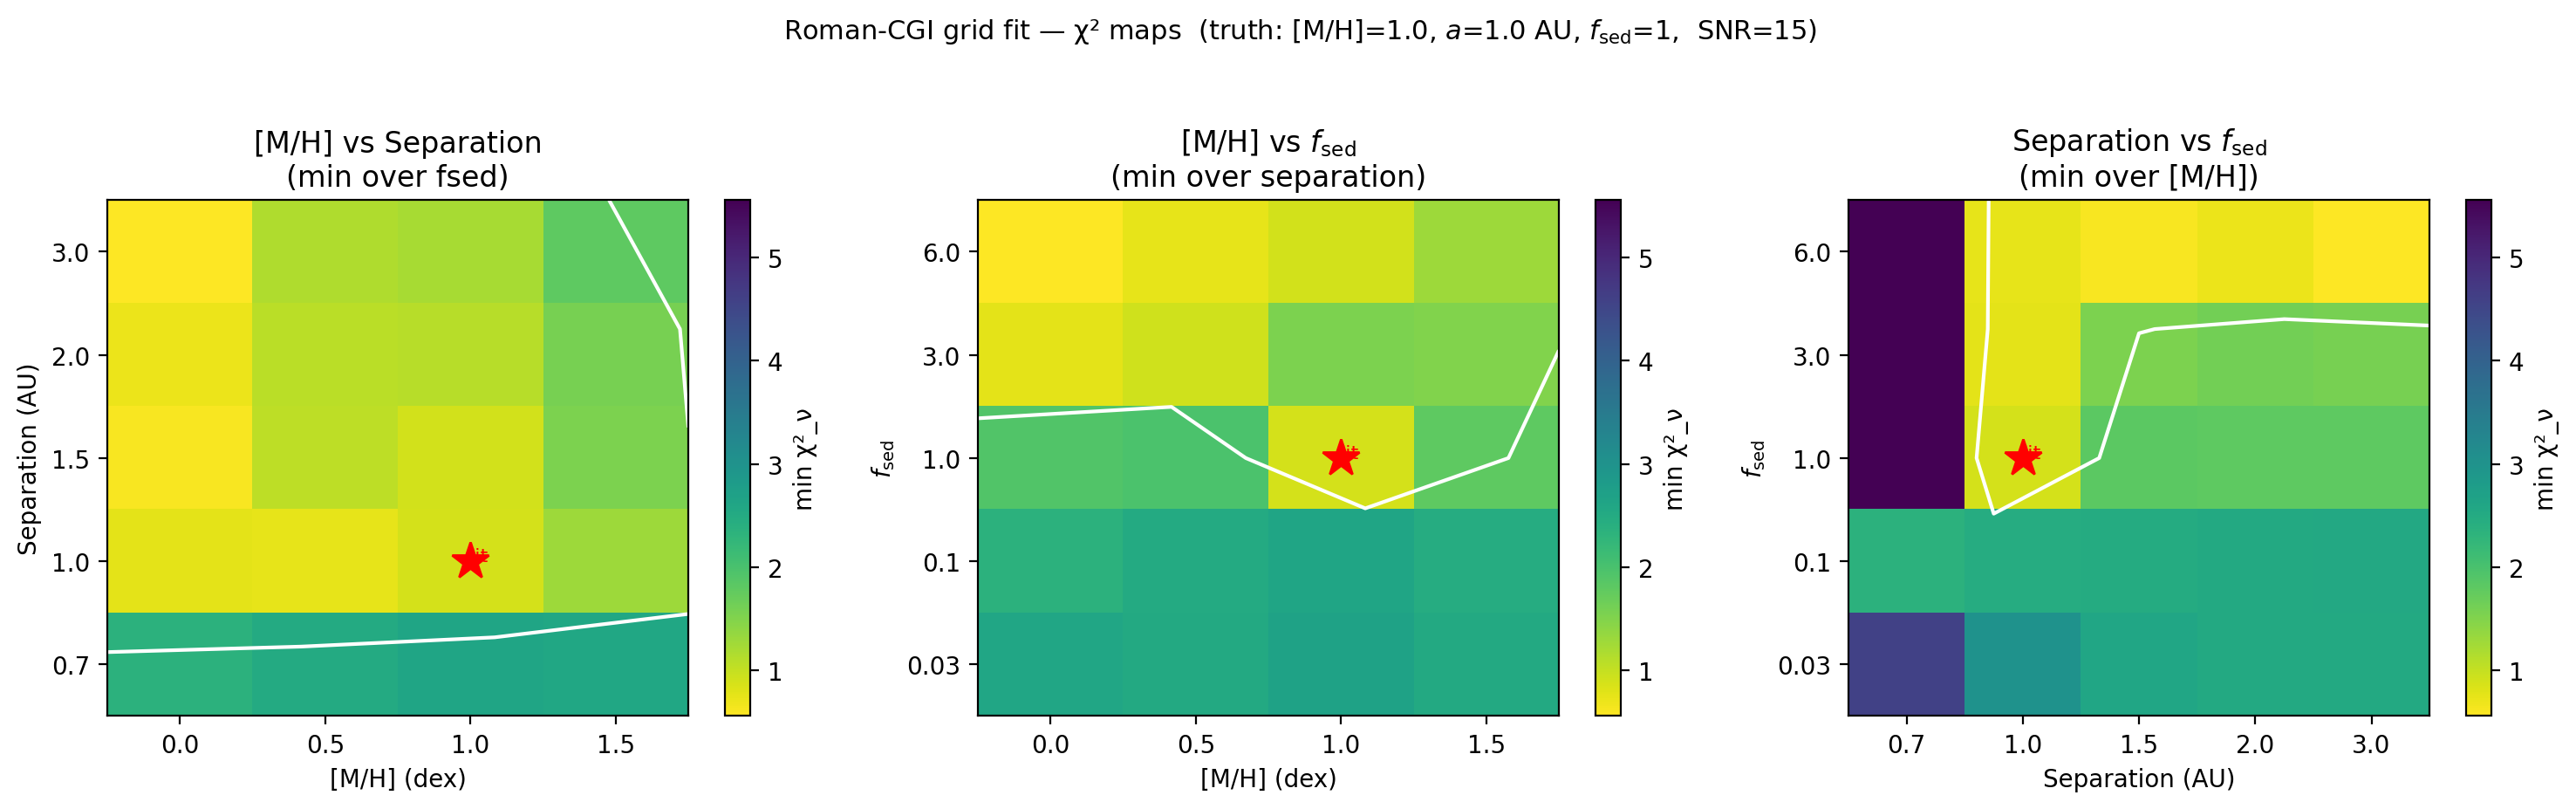

In [7]:
# ── Chi-squared maps (3 projections, each marginalised over the third axis) ──
mh_arr   = np.array(MH_GRID)
sep_arr  = np.array(SEP_GRID)
fsed_arr = np.array(FSED_GRID)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# [M/H] vs separation  (min over fsed)
rtu.plot_chi2_grid(axes[0],
                   chi2.min(axis=2), mh_arr, sep_arr,
                   '[M/H] (dex)', 'Separation (AU)',
                   '[M/H] vs Separation\n(min over fsed)',
                   TRUE_MH, TRUE_SEP)

# [M/H] vs fsed  (min over separation)
rtu.plot_chi2_grid(axes[1],
                   chi2.min(axis=1), mh_arr, fsed_arr,
                   '[M/H] (dex)', '$f_{\\rm sed}$',
                   '[M/H] vs $f_{\\rm sed}$\n(min over separation)',
                   TRUE_MH, TRUE_FSED)

# separation vs fsed  (min over [M/H])
rtu.plot_chi2_grid(axes[2],
                   chi2.min(axis=0), sep_arr, fsed_arr,
                   'Separation (AU)', '$f_{\\rm sed}$',
                   'Separation vs $f_{\\rm sed}$\n(min over [M/H])',
                   TRUE_SEP, TRUE_FSED)

plt.suptitle(f'Roman-CGI grid fit — χ² maps  '
             f'(truth: [M/H]={TRUE_MH}, $a$={TRUE_SEP} AU, '
             f'$f_{{\\rm sed}}$={TRUE_FSED},  SNR={SNR:.0f})',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()


> Those are some gnarly degeneracies! 

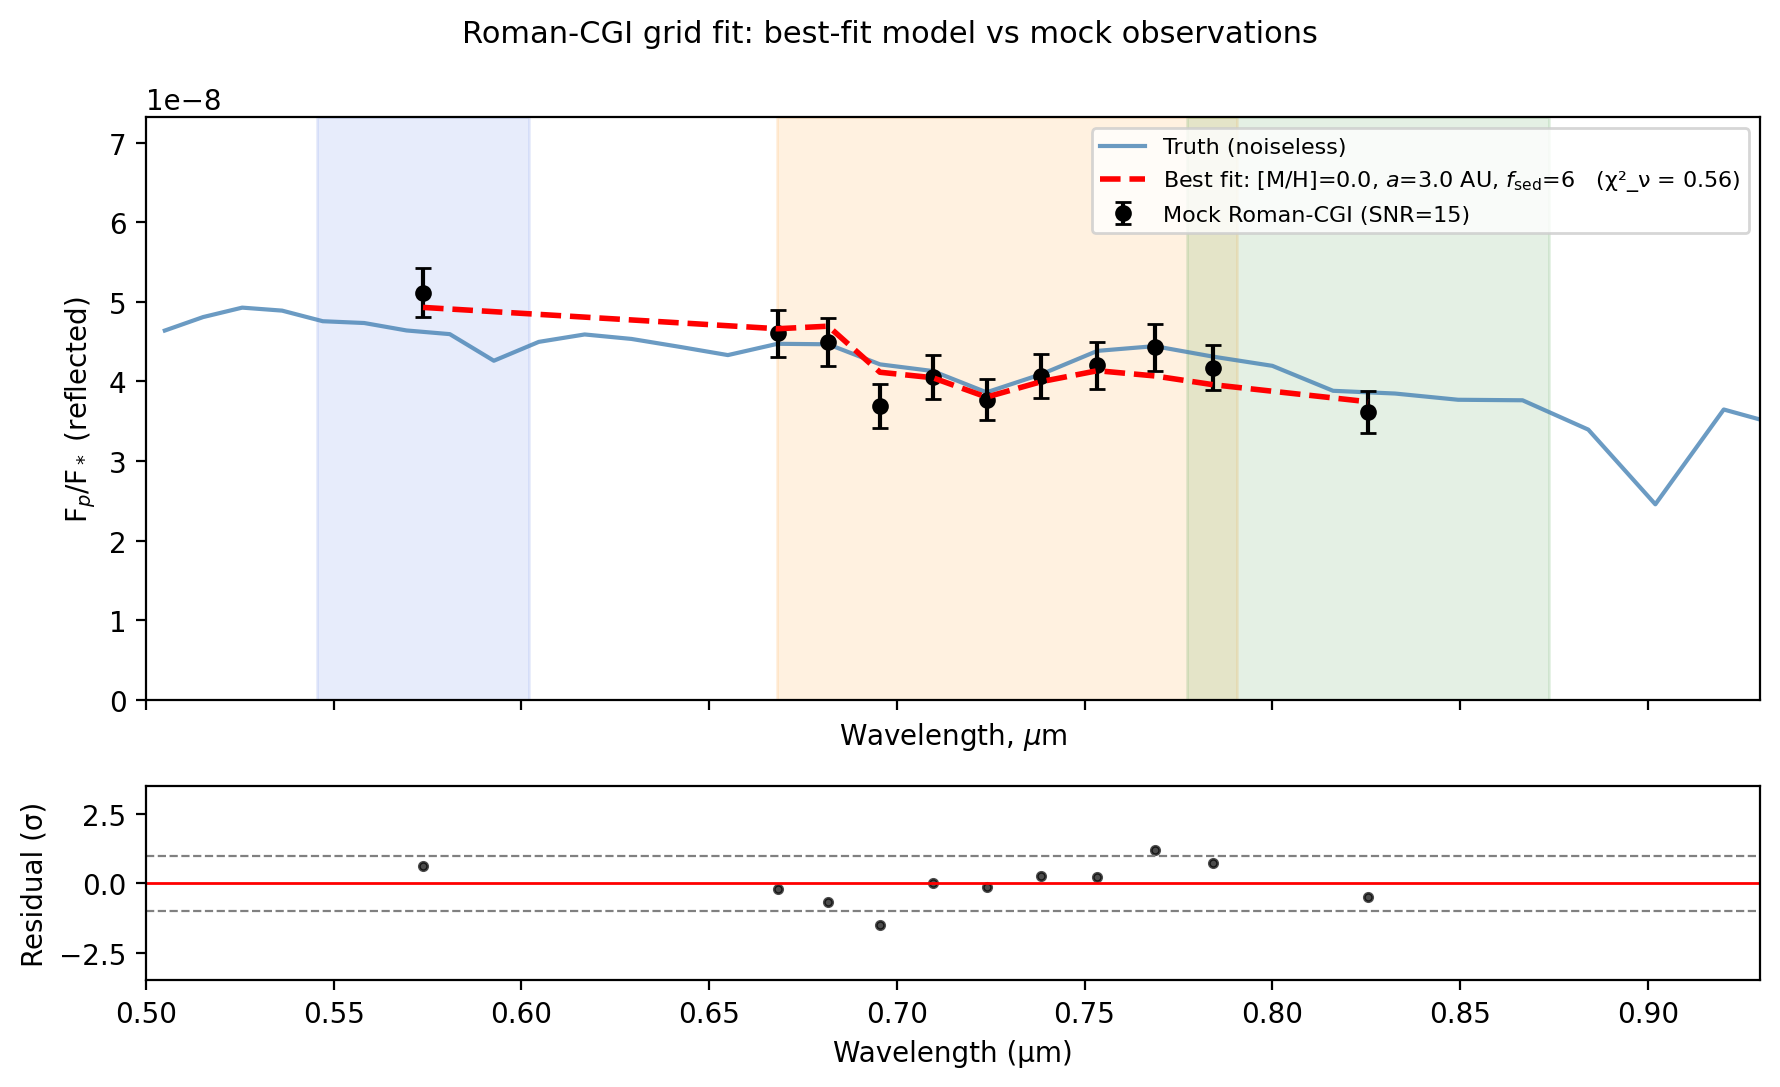

In [8]:
# ── Best-fit spectrum vs mock observations ───────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(9, 5.5), sharex=True,
                         gridspec_kw={'height_ratios': [3, 1]})
ax, ax_res = axes

# Noiseless truth
wno_r50, fpfs_r50 = jdi.mean_regrid(spec_true['wavenumber'],
                                    spec_true['fpfs_reflected'], R=50)
ax.plot(1e4 / wno_r50, fpfs_r50, color='steelblue', lw=1.5, alpha=0.8,
        label='Truth (noiseless)')

# Mock observations
ax.errorbar(wl_mock, fpfs_obs, yerr=fpfs_err,
            fmt='o', color='k', ms=5, elinewidth=1.5, capsize=3, zorder=5,
            label=f'Mock Roman-CGI (SNR={SNR:.0f})')

# Best-fit scaled model
ax.plot(wl_mock, C_best * best_model, 'r--', lw=2, zorder=6,
        label=(f'Best fit: [M/H]={best_mh}, $a$={best_sep} AU, '
               f'$f_{{\\rm sed}}$={best_fsed}   '
               f'(χ²_ν = {chi2[best_idx]:.2f})'))

ymax = max(fpfs_r50.max(), (fpfs_obs + fpfs_err).max()) * 1.35
rtu.format_roman_cgi_spectrum(ax, 0, ymax,
                              ylabel='F$_p$/F$_*$ (reflected)', xlim=(0.50, 0.93))
ax.legend(fontsize=8, ncol=1)

# Residuals panel
resid_norm = (fpfs_obs - C_best * best_model) / fpfs_err
ax_res.plot(wl_mock, resid_norm, 'k.', ms=6, alpha=0.7)
ax_res.axhline(0, color='r', lw=1)
ax_res.axhline(+1, color='gray', lw=0.8, ls='--')
ax_res.axhline(-1, color='gray', lw=0.8, ls='--')
ax_res.set_ylabel('Residual (σ)')
ax_res.set_ylim(-3.5, 3.5)
ax_res.set_xlabel('Wavelength (µm)')

plt.suptitle('Roman-CGI grid fit: best-fit model vs mock observations', fontsize=11)
plt.tight_layout()
plt.show()

Ideas for further exploration:
- Quick: adjust SNR lower and higher and recompute chi2 loop, what happens to posteriors?
- Quick: recompute compute chi2 loop with subsets of the observation coverage, how does this change results?
- Slower: change the seed for the random number generator and look at fit results, do they change significantly?
- Slower: what happens if you account for consistent separations with models and marginalize over a physically motivated range of radii? what if you limit to narrow range of separations since we'll have orbital information to constrain this?
- Slower: what can you gain by observing at more than one phase angle?


----------------------------
## <a id="SL"></a>Self-luminous Target

We want to investigate the degree to which Roman-CGI observations give us additional information about young self-luminous targets where we already have IR observations. 

We'll use $\beta$-Pic b as a case study. It is one of the best-characterized directly imaged planets, with observations spanning optical through mid-infrared wavelengths. We'll take Teff and log(g) from **GRAVITY+ 2020 literature values** and search for the Kzz, fsed, and combination of cloud species which best reproduce the IR SED. From that model we'll generate mock Roman-CGI observations. Finally we'll compare how IR alone vs IR+Roman-CGI do fitting for Teff, log(g) and fsed.


### Loading Observational IR Data

Here we load observations from the EWI database, which compiles multi-instrument spectra for most directly-imaged substellar companions in a uniform FITS format. A function in roman_tutorial_utils.py handles file input for us.

In [10]:
DATA_DIR = os.path.join('Data', 'ewi-data', 'BetaPicb', 'ForMated')
obs = rtu.load_ewi_data(DATA_DIR, exclude=('SINFONI-K4000',))

# Unpack into local names so all downstream cells work unchanged
all_data        = obs['all_data']         # all instruments (including excluded) — rarely needed
plot_data       = obs['plot_data']        # excluded instruments removed — use for SED plots
wl_obs          = obs['wl']               #  wavelength in µm
flx_obs         = obs['flx']              # flux in W m⁻² µm⁻¹
err_obs         = obs['err']              # flux uncertainty in W m⁻² µm⁻¹
is_phot         = obs['is_phot']
is_spec         = obs['is_spec']
wno_spec        = obs['wno_spec']
phot_bandpasses = obs['phot_bandpasses']
phot_idx        = obs['phot_idx']
N_DATA = len(wl_obs);  N_SPEC = int(is_spec.sum());  N_PHOT = int(is_phot.sum())

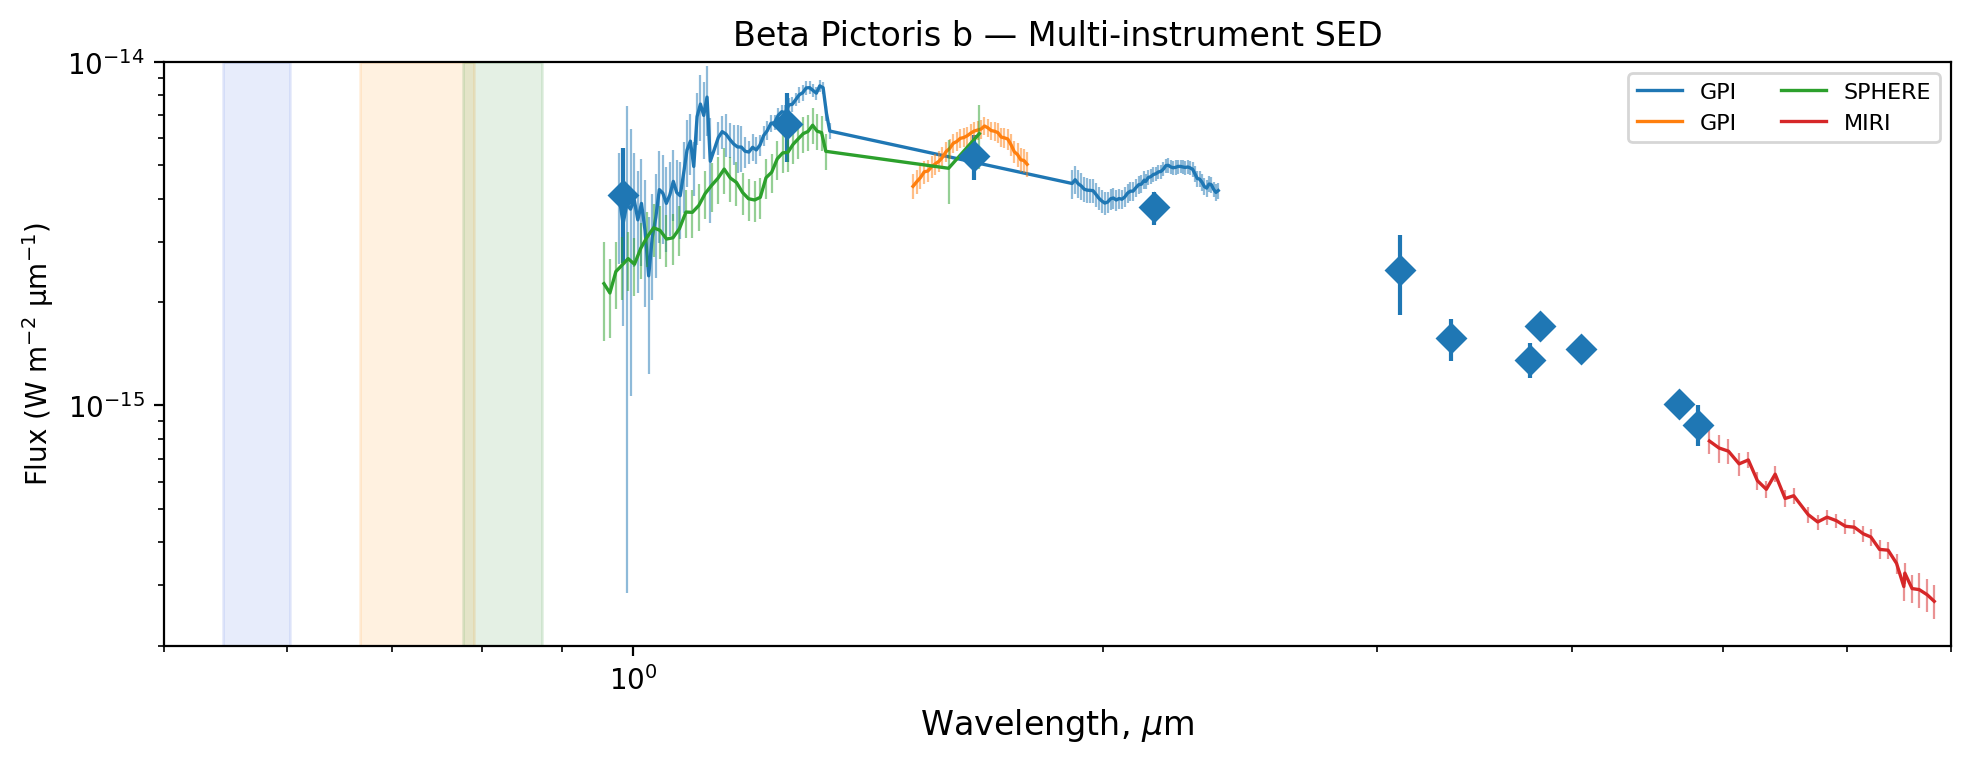

In [11]:
fig, ax = plt.subplots(figsize=(10, 4))

colors = plt.cm.tab10.colors
for i, d in enumerate(plot_data):   # plot_data excludes SINFONI-K4000 and any other excluded instruments
    c = colors[i % len(colors)]
    label = d['ins']
    _is_phot = d['res'] == 0   # loop-local; underscore avoids shadowing notebook-scope is_phot
    _is_spec = ~_is_phot

    # Spectral channels: line + thin errorbars
    if np.any(_is_spec):
        ax.errorbar(d['wav'][_is_spec], d['flx'][_is_spec], yerr=d['err'][_is_spec],
                    fmt='none', color=c, elinewidth=0.8, alpha=0.5)
        ax.plot(d['wav'][_is_spec], d['flx'][_is_spec], '-', color=c,
                lw=1.2, label=label)
        label = None  # avoid duplicate legend entry for photometric points

    # Photometric points: filled diamond markers
    if np.any(_is_phot):
        ax.errorbar(d['wav'][_is_phot], d['flx'][_is_phot], yerr=d['err'][_is_phot],
                    fmt='D', color=c, ms=7, elinewidth=1.5,
                    label=label)

ax.set_xlabel('Wavelength (µm)', fontsize=12)
ax.set_title('Beta Pictoris b — Multi-instrument SED')
ax.set_xscale('log')
ax.set_yscale('log')
ax.legend(fontsize=8, ncol=2)
rtu.format_roman_cgi_spectrum(ax,2e-16,1e-14,xlim=(0.5,7),ylabel='Flux (W m$^{-2}$ µm$^{-1}$)')
plt.tight_layout()
plt.show()

We'll need opacities that extend out to longer wavelengths for this data

In [12]:
# Load opacity DB over the full range covered by optical + NIR-MIR data (0.5 – 7 µm)
opa = jdi.opannection(wave_range=[0.5, 7.0],filename_db=opacity_db)

### Generating mock Roman-CGI observations

First we have to assume some parameter values. Let's take Teff and log g from the GRAVITY+ 2020 paper, and pick cloud properties that do a reasonable job fitting NIR observations. 

In [13]:
# ── Snap literature Teff/logg to nearest Sonora Bobcat grid points ────────────
# GRAVITY+ 2020: Teff ≈ 1724 K, log g ≈ 4.18  (g ≈ 151 m/s²)
TEFF_LIT = 1700    # K     — nearest Sonora grid point to 1724 K
GRAV_LIT = 316     # m/s²  — nearest Sonora grid point to 151 m/s² (log g = 4.25)
LOGG_LIT = round(np.log10(GRAV_LIT * 100), 2)
D_TARGET_PC = 19.44

# Cloud species to include if thermodynamically recommended by virga
TARGET_CLOUDS = ['Fe', 'Mg2SiO4']
cloud_label_fixed = 'Fe+Mg2SiO4'
kzz_simdata = 1e8
fsed_simdata = 4.0

Generate a spectrum and calculate a normalization factor that best matches this spectrum to observations.

In [14]:
#calculate spectra
bd_truth = jdi.inputs(calculation='browndwarf')
bd_truth.gravity(gravity=GRAV_LIT, gravity_unit=u.Unit('m/s**2'))
bd_truth.phase_angle(0)
bd_truth.sonora(sonora_db, TEFF_LIT)
bd_truth.inputs['atmosphere']['profile']['kz'] = kzz_simdata
profile_truth = bd_truth.inputs['atmosphere']['profile']
rec_truth = vj.recommend_gas(profile_truth['pressure'], profile_truth['temperature'], mh=1, mmw=2.2)
active_truth = [g for g in TARGET_CLOUDS if g in rec_truth]
if active_truth:
    bd_truth.virga(active_truth, virga_dir, fsed=fsed_simdata, mh=1, mmw=2.2,verbose=False)

with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    spec_truth = bd_truth.spectrum(opa)

#match it to NIR observations
wno_truth    = spec_truth['wavenumber']
wl_truth     = 1e4 / wno_truth
fl_truth     = spec_truth['thermal'] * 1e-7

model_truth = np.empty(N_DATA)

# Spectroscopic points: bin to observed spectral resolution
_, fl_spec = jdi.mean_regrid(wno_truth, fl_truth, newx=wno_spec)
model_truth[is_spec] = fl_spec[::-1]

# Photometric points: average over true filter bandpass
for m, (lmin, lmax) in enumerate(phot_bandpasses):
    bp_mask = (wl_truth >= lmin) & (wl_truth <= lmax)
    model_truth[phot_idx[m]] = np.mean(fl_truth[bp_mask])

#analytic expression for scale factor to minimize chi2
C_truth = (np.sum(flx_obs * model_truth / err_obs**2) /   # Bug 4 fix: flx_obs (not flx_obs[N_RCGI:])
     np.sum(model_truth**2 / err_obs**2))

In [15]:
# ── Infer the planet radius from the normalization constant C ───────────────
#
# After converting the model to W/m²/µm in the grid loop, the analytic scale
# factor C minimises chi-sq such that:
#
#   F_obs = C × F_model   →   C = (R_planet / d)²
#
# Solving for R:   R_planet = d × √C

D_PC     = 10.0               # Hipparcos distance to Beta Pic (pc) is 19.44... but this data seems to be at 10 pc?
PC_TO_M  = 3.085677581e16     # 1 parsec in metres
R_JUP_M  = 7.1492e7           # Jupiter radius in metres

d_m           = 10.0 * PC_TO_M
R_planet_m    = d_m * np.sqrt(C_truth) 
R_planet_Rjup = R_planet_m / R_JUP_M

print(R_planet_Rjup)

1.0954045274582025


Now let's bin to Roman-CGI observations and add noise.

In [16]:
SNR_RCGI = 20   # SNR per Roman-CGI channel, this is quite optimistic

fl_truth_scaled = C_truth * fl_truth     # W/m²/µm at Earth, 2D best-fit

# ── Generate mock Roman-CGI data from the 2D best-fit (fixed Teff/logg) ──────
spec_dict = {'wavenumber': wno_truth, 'fl_wm2': fl_truth_scaled}
b1_rc, b3_rc, b4_rc = rtu.mimic_roman_cgi_obs(spec_dict, spec_key='fl_wm2')

wl_rcgi       = np.concatenate([[b1_rc[0]], b3_rc[0], [b4_rc[0]]])
flx_rcgi_true = np.concatenate([[b1_rc[1]], b3_rc[1], [b4_rc[1]]])
err_rcgi      = np.abs(flx_rcgi_true) / SNR_RCGI
wno_truth_scaled_R50, fl_truth_scaled_R50 = jdi.mean_regrid(wno_truth,fl_truth_scaled,R=50)

np.random.seed(7)
flx_rcgi = flx_rcgi_true + np.random.normal(0, err_rcgi, size=len(flx_rcgi_true))
N_RCGI   = len(wl_rcgi)

print(f"Roman-CGI mock: {N_RCGI} data points  (1 B1 + {len(b3_rc[0])} B3 + 1 B4)")

Roman-CGI mock: 11 data points  (1 B1 + 9 B3 + 1 B4)


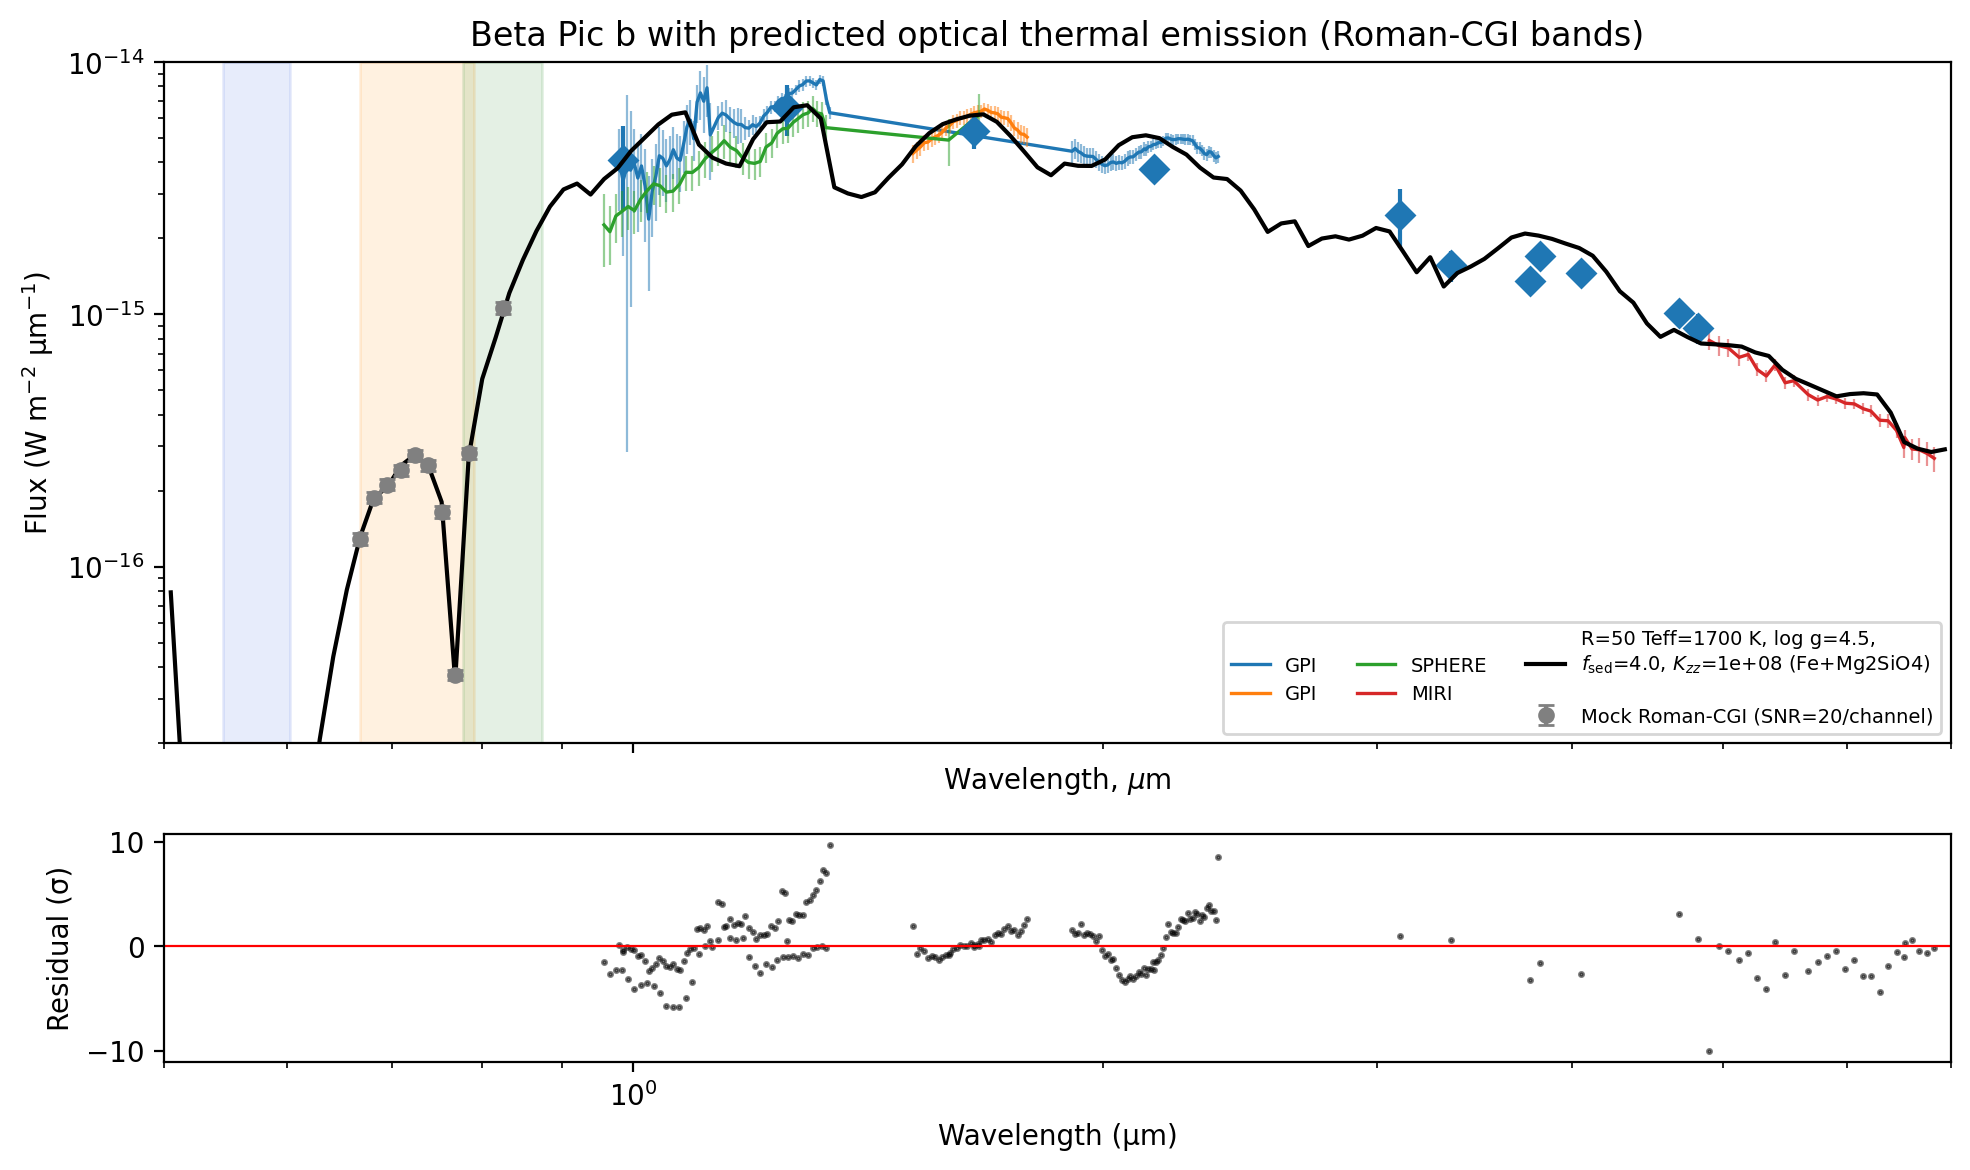

In [38]:
# ── "Truth" used for mock Roman-CGI data plotted with NIR data  
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True,
                         gridspec_kw={'height_ratios': [3, 1]})
ax, ax_res = axes

# Observations colored by instrument
colors_inst = plt.cm.tab10.colors
for k, d in enumerate(plot_data):
    c = colors_inst[k % len(colors_inst)]
    is_phot_d = d['res'] == 0
    is_spec_d = ~is_phot_d
    kw = dict(color=c, label=d['ins'])
    if np.any(is_spec_d):
        ax.errorbar(d['wav'][is_spec_d], d['flx'][is_spec_d], d['err'][is_spec_d],
                    fmt='none', color=c, elinewidth=0.8, alpha=0.5)
        ax.plot(d['wav'][is_spec_d], d['flx'][is_spec_d], '-', **kw, lw=1.2)
        kw.pop('label')
    if np.any(is_phot_d):
        ax.errorbar(d['wav'][is_phot_d], d['flx'][is_phot_d], d['err'][is_phot_d],
                    fmt='D', ms=7, elinewidth=1.5, **kw)

# 2D fixed-Teff/logg best-fit model
ax.plot(1e4/wno_truth_scaled_R50, fl_truth_scaled_R50, 'k-', lw=1.5, zorder=5,
        label=(f'R=50 Teff={TEFF_LIT} K, log g={LOGG_LIT},\n'
               f'$f_{{\\rm sed}}$={fsed_simdata}, '
               f'$K_{{zz}}$={kzz_simdata:.0e} ({cloud_label_fixed})\n'))

# Residuals for NIR
resid_fixed = (flx_obs - C_truth * model_truth) / (err_obs)
ax_res.plot(wl_obs, resid_fixed, 'k.', ms=3, alpha=0.5)
ax_res.axhline(0, color='r', lw=0.8)
ax_res.set_ylabel('Residual (σ)')
ax_res.set_xlabel('Wavelength (µm)')

# ── Roman-CGI wavlengths -------------------

# Mock observations (generated from 2D best-fit)
ax.errorbar(wl_rcgi, flx_rcgi, yerr=err_rcgi, fmt='o', color='gray',
            ms=5, capsize=3, zorder=5, label=f'Mock Roman-CGI (SNR={SNR_RCGI}/channel)')

ax.set_yscale('log')
ax.set_xscale('log')
ax.legend(fontsize=7, ncol=3)
ax.set_title('Beta Pic b with predicted optical thermal emission (Roman-CGI bands)')
rtu.format_roman_cgi_spectrum(ax,2e-17,1e-14,xlim=(0.5,7),ylabel='Flux (W m$^{-2}$ µm$^{-1}$)')

plt.tight_layout()
plt.show()

### Fitting IR data vs. IR+Roman-CGI for Teff, log g, fsed, and Kzz

We search a grid of PICASO/Sonora Bobcat models to find the Teff, log g, and cloud sedimentation efficiency ($f_\mathrm{sed}$) that best match the observed SED. $K_{zz}$ is fixed at the best-fit value found in the 2D fit above (`best_kzz_fixed`).

For each grid point we:
1. Load the Sonora Bobcat T-P profile
2. Call `virga.recommend_gas` to check which of Fe and Mg₂SiO₄ are thermodynamically stable at this Teff/log g. Only the recommended species are passed to `virga`; if none are recommended the calculation proceeds as a clear atmosphere.
4. Run a PICASO thermal emission spectrum
5. For IR wavelengths: regrid to match observations
6. For optical wavelengths: regrid to match observations

**Grid**: Teff ∈ {1600, 1700, 1800} K × log g ∈ {3.75, 4.0, 4.25} × $f_\mathrm{sed}$ ∈ {2, 4, 6} × K$_{zz}$ ∈ {1e7, 1e8, 1e9} → **81 models** total.

In [20]:
# ── Grid definition ──────────────────────────────────────────────────────────
TEFF_GRID = [1600, 1700, 1800]   # K
GRAV_GRID = [178, 316, 562]      # m/s²
LOGG_GRID = [round(np.log10(g * 100), 2) for g in GRAV_GRID]
FSED_GRID = [2.0, 4.0, 6.0]      # sedimentation efficiency
KZZ_GRID  = [1e7, 1e8, 1e9]      # cm²/s — vertical mixing

dims = (len(TEFF_GRID), len(GRAV_GRID), len(FSED_GRID), len(KZZ_GRID))
grid_data          = np.full((*dims, N_DATA+N_RCGI), np.nan)
clouds_recommended = np.zeros(dims, dtype=bool)     # True when ≥1 target cloud is recommended

print(f"Grid: {len(TEFF_GRID)} Teff × {len(GRAV_GRID)} log g × {len(FSED_GRID)} fsed "
      f"× {len(KZZ_GRID)} Kzz = {int(np.prod(dims))} models\n")

with tqdm(total=int(np.prod(dims)), desc='Sonora+virga grid') as pbar:
    for i, teff in enumerate(TEFF_GRID):
        for j, grav in enumerate(GRAV_GRID):
            for k, fsed in enumerate(FSED_GRID):
                for l, kzz in enumerate(KZZ_GRID):
                    try:
                        bd = jdi.inputs(calculation='browndwarf')
                        bd.gravity(gravity=grav, gravity_unit=u.Unit('m/s**2'))
                        bd.phase_angle(0)
                        bd.sonora(sonora_db, teff)

                        # Set Kzz column (needed by virga for particle size calculation)
                        bd.inputs['atmosphere']['profile']['kz'] = kzz

                        # Check which target clouds are thermodynamically stable at this T-P
                        profile = bd.inputs['atmosphere']['profile']
                        recommended = vj.recommend_gas(profile['pressure'],
                                                       profile['temperature'],
                                                       mh=1, mmw=2.2)
                        active_clouds = [g for g in TARGET_CLOUDS if g in recommended]
                        clouds_recommended[i, j, k, l] = len(active_clouds) > 0

                        if clouds_recommended[i, j, k, l]:
                            # Include only the recommended subset of the target cloud species
                            bd.virga(active_clouds, virga_dir, fsed=fsed, mh=1, mmw=2.2)
                        # else: no bd.virga() call → clear atmosphere spectrum

                        with warnings.catch_warnings():
                            warnings.simplefilter('ignore')
                            spec = bd.spectrum(opa, full_output=True)

                        wno_m = spec['wavenumber']
                        wl_m  = 1e4 / wno_m
                        fl_m  = spec['thermal']

                        # NIR data
                        model_vec = np.empty(N_DATA)

                        # Spectroscopic points: bin to observed spectral resolution
                        _, fl_spec = jdi.mean_regrid(wno_m, fl_m, newx=wno_spec)
                        model_vec[is_spec] = fl_spec[::-1]

                        # Photometric points: average over true filter bandpass
                        for m, (lmin, lmax) in enumerate(phot_bandpasses):
                            bp_mask = (wl_m >= lmin) & (wl_m <= lmax)
                            model_vec[phot_idx[m]] = np.mean(fl_m[bp_mask])

                        # Roman-CGI optical bands
                        cgi_vec = np.empty(N_RCGI)
                        b1, b3, b4 = rtu.mimic_roman_cgi_obs(
                            {'wavenumber': wno_m, 'thermal': fl_m}, spec_key='thermal')
                        cgi_vec[0]    = b1[1]
                        cgi_vec[1:-1] = b3[1]
                        cgi_vec[-1]   = b4[1]

                        grid_data[i, j, k, l, :] = np.concatenate([cgi_vec, model_vec]) * 1e-7

                    except Exception:
                        pass   # grid_data stays nan → chi² = inf for this point

                    pbar.update(1)

n_ok    = np.sum(np.all(np.isfinite(grid_data), axis=-1))
n_cloud = int(clouds_recommended.sum())
print(f"\nSuccessfully computed : {n_ok} / {int(np.prod(dims))} models")
print(f"Clouds recommended   : {n_cloud} / {int(np.prod(dims))} grid points "
      f"(at least one of Fe/Mg2SiO4 stable)")

Grid: 3 Teff × 3 log g × 3 fsed × 3 Kzz = 81 models



Sonora+virga grid: 100%|████████████████████████| 81/81 [04:33<00:00,  3.37s/it]


Successfully computed : 81 / 81 models
Clouds recommended   : 81 / 81 grid points (at least one of Fe/Mg2SiO4 stable)


Now we loop through grid again and evaluate two χ² values, one for optical+IR data and  one for IR data alone

In [39]:
chi2_ir      = np.full(dims, np.inf)
chi2_joint   = np.full(dims, np.inf)
C_grid_ir    = np.zeros(dims)
C_grid_joint = np.zeros(dims)

full_flx_obs = np.concatenate([flx_rcgi, flx_obs])
full_err_obs = np.concatenate([err_rcgi, err_obs])
full_wl_obs  = np.concatenate([wl_rcgi, wl_obs])

for i in range(len(TEFF_GRID)):
    for j in range(len(GRAV_GRID)):
        for k in range(len(FSED_GRID)):
            for l in range(len(KZZ_GRID)):

                # IR only (last N_DATA entries of grid_data)
                model = grid_data[i, j, k, l, N_RCGI:]
                if np.any(np.isnan(model)):
                    continue
                C = (np.sum(flx_obs * model / err_obs**2) /
                     np.sum(model**2 / err_obs**2))
                resid = flx_obs - C * model
                chi2_ir[i, j, k, l]   = np.sum(resid**2 / err_obs**2) / (N_DATA - 1)
                C_grid_ir[i, j, k, l] = C

                # IR + optical (full N_DATA+N_RCGI entries)
                model = grid_data[i, j, k, l, :]
                if np.any(np.isnan(model)):
                    continue
                C = (np.sum(full_flx_obs * model / full_err_obs**2) /
                     np.sum(model**2 / full_err_obs**2))
                resid = full_flx_obs - C * model
                chi2_joint[i, j, k, l]   = np.sum(resid**2 / full_err_obs**2) / (N_DATA + N_RCGI - 1)
                C_grid_joint[i, j, k, l] = C

# ── Results for NIR only ──────────────────────────────────────────────────────
best_ij   = np.unravel_index(np.nanargmin(chi2_ir), dims)
best_teff = TEFF_GRID[best_ij[0]]
best_logg = LOGG_GRID[best_ij[1]]
best_fsed = FSED_GRID[best_ij[2]]
best_kzz  = KZZ_GRID [best_ij[3]]
C_best         = C_grid_ir[best_ij]
best_model     = grid_data[best_ij]
best_clouds_active = clouds_recommended[best_ij]

print(f"Best-fit Teff IR only  = {best_teff} K     (published: ~1724 K)")
print(f"Best-fit log g IR only = {best_logg}       (published: ~4.18–4.46)")
print(f"Best-fit fsed  IR only = {best_fsed}")
print(f"Best-fit Kzz   IR only = {best_kzz:.0e} cm²/s  (truth: {kzz_simdata:.0e})")
print(f"Clouds active  IR only : {best_clouds_active}  "
      f"({'Fe/Mg2SiO4' if best_clouds_active else 'clear atmosphere — no target clouds stable'})")
print(f"Best-fit χ²    IR only = {chi2_ir[best_ij]:.3f}\n")

# ── Results for joint fit ─────────────────────────────────────────────────────
best_ij_joint   = np.unravel_index(np.nanargmin(chi2_joint), dims)
best_teff_joint = TEFF_GRID[best_ij_joint[0]]
best_logg_joint = LOGG_GRID[best_ij_joint[1]]
best_fsed_joint = FSED_GRID[best_ij_joint[2]]
best_kzz_joint  = KZZ_GRID [best_ij_joint[3]]
C_best_joint    = C_grid_joint[best_ij_joint]
best_model_joint = grid_data[best_ij_joint]
best_clouds_active_joint = clouds_recommended[best_ij_joint]

print(f"Best-fit Teff IR+optical  = {best_teff_joint} K  (published: ~1724 K)")
print(f"Best-fit log g IR+optical = {best_logg_joint}    (published: ~4.18–4.46)")
print(f"Best-fit fsed  IR+optical = {best_fsed_joint}")
print(f"Best-fit Kzz   IR+optical = {best_kzz_joint:.0e} cm²/s  (truth: {kzz_simdata:.0e})")
print(f"Clouds active  IR+optical : {best_clouds_active_joint}  "
      f"({'Fe/Mg2SiO4' if best_clouds_active_joint else 'clear atmosphere — no target clouds stable'})")
print(f"Best-fit χ²    IR+optical = {chi2_joint[best_ij_joint]:.3f}")

Best-fit Teff IR only  = 1700 K     (published: ~1724 K)
Best-fit log g IR only = 4.5       (published: ~4.18–4.46)
Best-fit fsed  IR only = 4.0
Best-fit Kzz   IR only = 1e+08 cm²/s  (truth: 1e+08)
Clouds active  IR only : True  (Fe/Mg2SiO4)
Best-fit χ²    IR only = 6.483

Best-fit Teff IR+optical  = 1700 K  (published: ~1724 K)
Best-fit log g IR+optical = 4.5    (published: ~4.18–4.46)
Best-fit fsed  IR+optical = 4.0
Best-fit Kzz   IR+optical = 1e+08 cm²/s  (truth: 1e+08)
Clouds active  IR+optical : True  (Fe/Mg2SiO4)
Best-fit χ²    IR+optical = 6.221


Let's visualize these results.

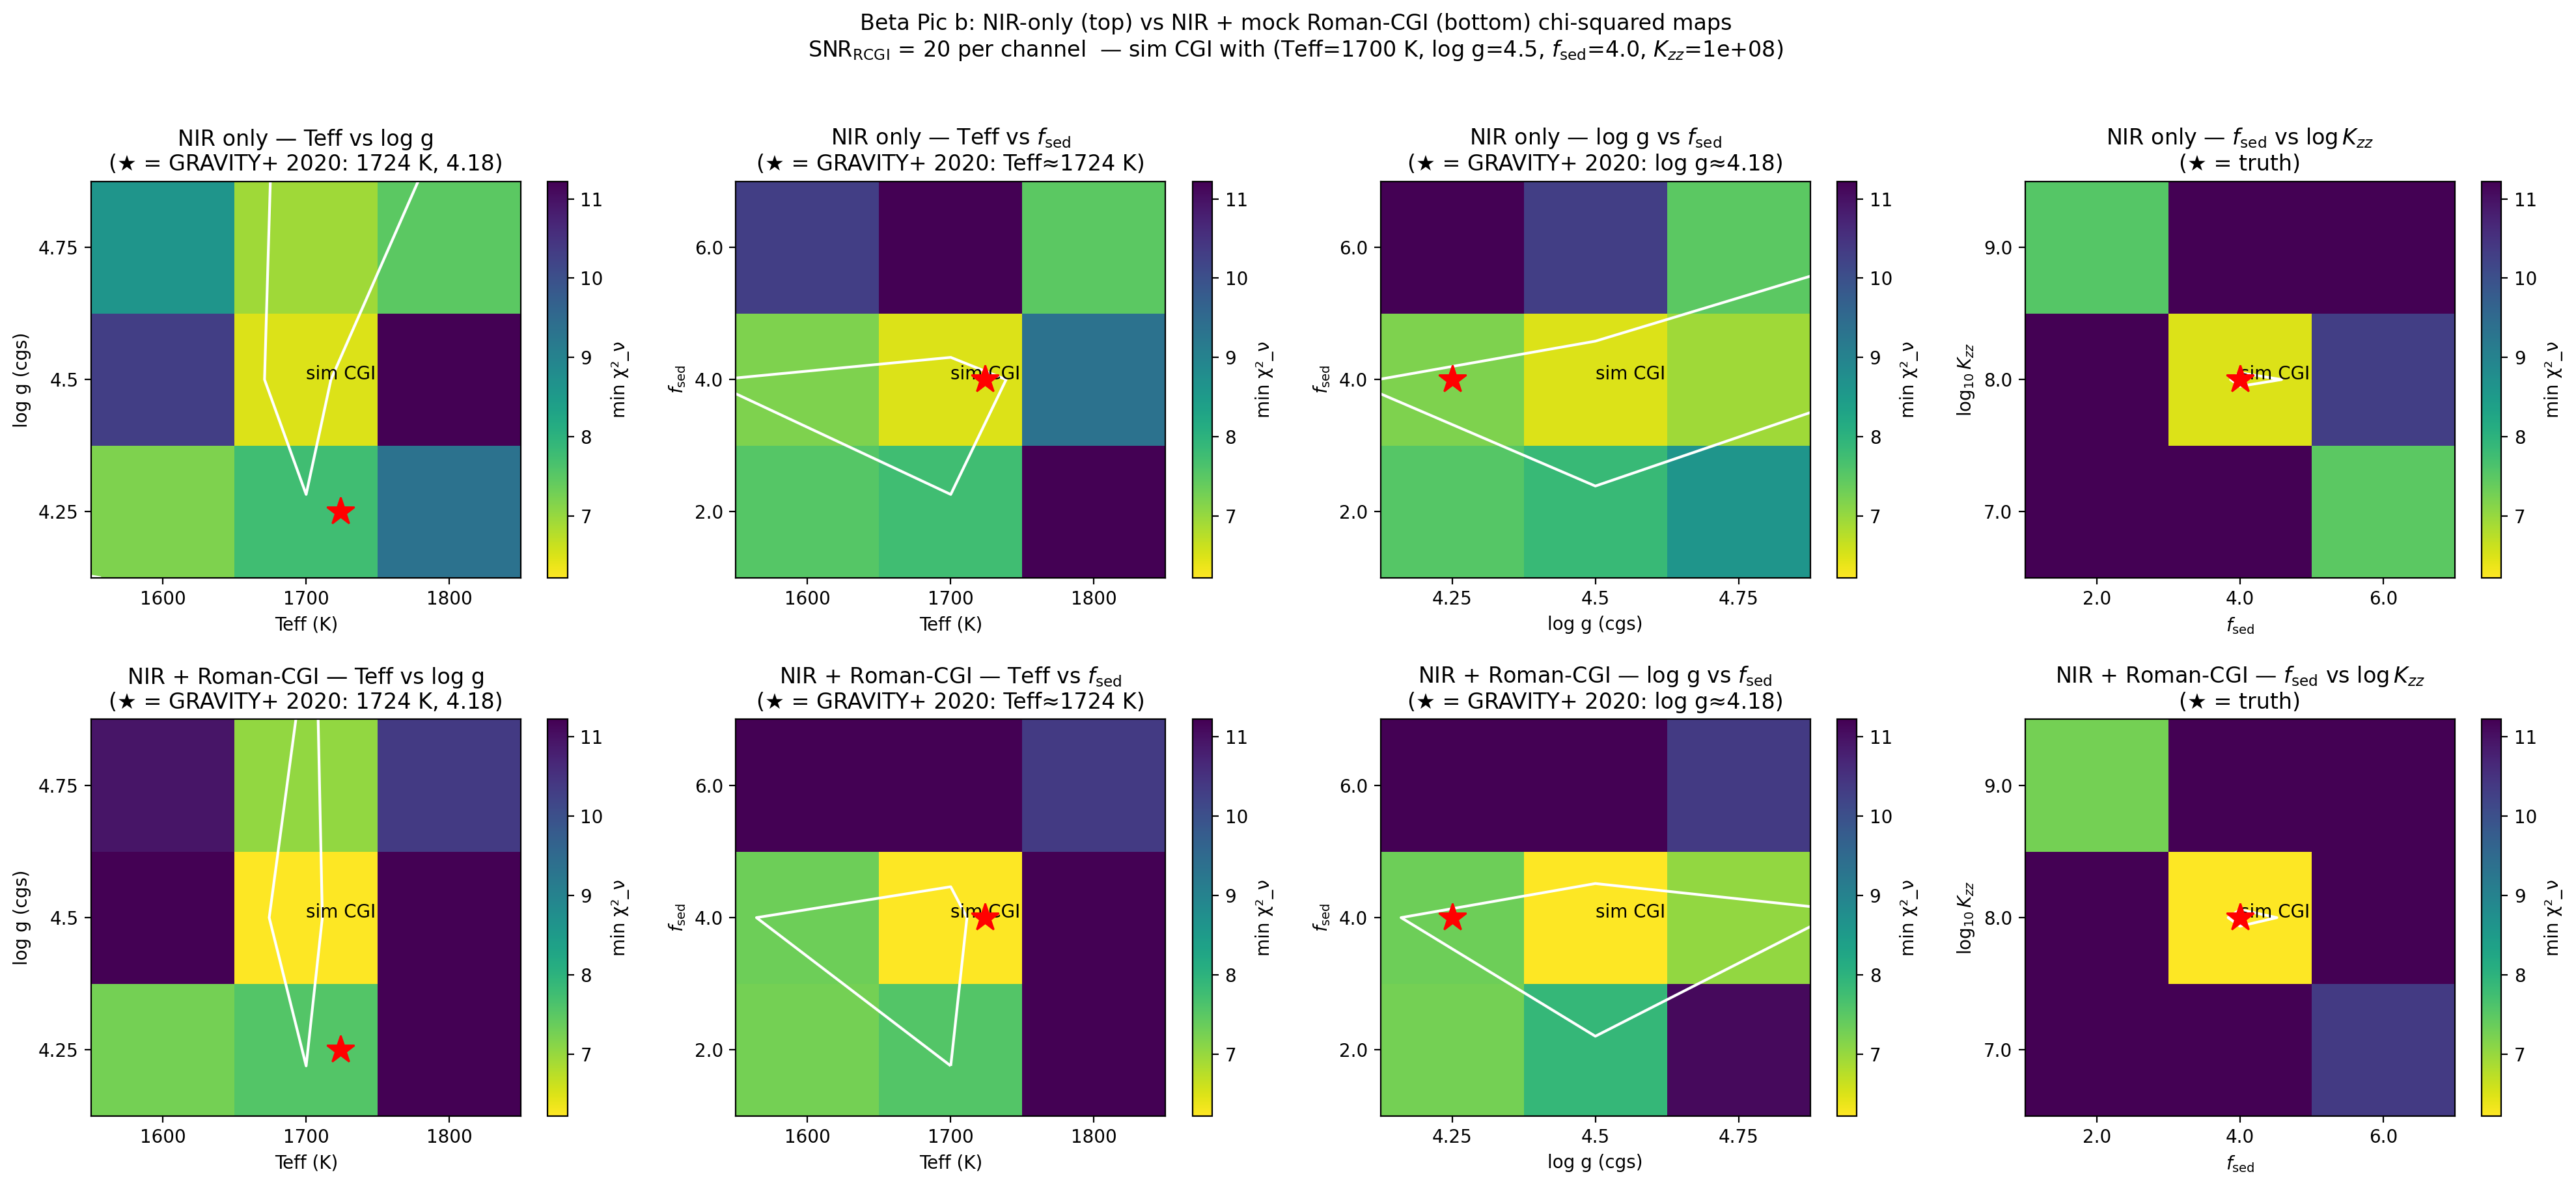

In [40]:
teff_arr    = np.array(TEFF_GRID)
logg_arr    = np.array(LOGG_GRID)
fsed_arr    = np.array(FSED_GRID)
kzz_log_arr = np.log10(np.array(KZZ_GRID))   # plot on log scale

# ── Comparison: NIR-only vs NIR + Roman-CGI chi-squared maps ─────────────────
# Both rows share the same chi2 scale so the tightening of constraints is
# directly visible.  We compute chi2_min once and pass it to every panel.
chi2_min_shared = min(float(np.nanmin(chi2_ir[np.isfinite(chi2_ir)])),
                      float(np.nanmin(chi2_joint[np.isfinite(chi2_joint)])))

fig, axes = plt.subplots(2, 4, figsize=(20, 9))

# ── Row 1: NIR only ────────────────────────────────────────────────────────────
rtu.plot_chi2_grid(axes[0, 0],
                   chi2_ir.min(axis=(2,3)), teff_arr, logg_arr,
                   'Teff (K)', 'log g (cgs)',
                   'NIR only — Teff vs log g\n(★ = GRAVITY+ 2020: 1724 K, 4.18)',
                   1724, 4.18, chi2_min=chi2_min_shared)

rtu.plot_chi2_grid(axes[0, 1],
                   chi2_ir.min(axis=(1,3)), teff_arr, fsed_arr,
                   'Teff (K)', '$f_{\\rm sed}$',
                   'NIR only — Teff vs $f_{\\rm sed}$\n(★ = GRAVITY+ 2020: Teff≈1724 K)',
                   1724, fsed_simdata, chi2_min=chi2_min_shared)

rtu.plot_chi2_grid(axes[0, 2],
                   chi2_ir.min(axis=(0,3)), logg_arr, fsed_arr,
                   'log g (cgs)', '$f_{\\rm sed}$',
                   'NIR only — log g vs $f_{\\rm sed}$\n(★ = GRAVITY+ 2020: log g≈4.18)',
                   4.18, fsed_simdata, chi2_min=chi2_min_shared)

rtu.plot_chi2_grid(axes[0, 3],
                   chi2_ir.min(axis=(0,1)), fsed_arr, kzz_log_arr,
                   '$f_{\\rm sed}$', '$\\log_{10} K_{zz}$',
                   'NIR only — $f_{\\rm sed}$ vs $\\log K_{zz}$\n(★ = truth)',
                   fsed_simdata, np.log10(kzz_simdata), chi2_min=chi2_min_shared)

# ── Row 2: NIR + Roman-CGI ─────────────────────────────────────────────────────
rtu.plot_chi2_grid(axes[1, 0],
                   chi2_joint.min(axis=(2,3)), teff_arr, logg_arr,
                   'Teff (K)', 'log g (cgs)',
                   'NIR + Roman-CGI — Teff vs log g\n(★ = GRAVITY+ 2020: 1724 K, 4.18)',
                   1724, 4.18, chi2_min=chi2_min_shared)

rtu.plot_chi2_grid(axes[1, 1],
                   chi2_joint.min(axis=(1,3)), teff_arr, fsed_arr,
                   'Teff (K)', '$f_{\\rm sed}$',
                   'NIR + Roman-CGI — Teff vs $f_{\\rm sed}$\n(★ = GRAVITY+ 2020: Teff≈1724 K)',
                   1724, fsed_simdata, chi2_min=chi2_min_shared)

rtu.plot_chi2_grid(axes[1, 2],
                   chi2_joint.min(axis=(0,3)), logg_arr, fsed_arr,
                   'log g (cgs)', '$f_{\\rm sed}$',
                   'NIR + Roman-CGI — log g vs $f_{\\rm sed}$\n(★ = GRAVITY+ 2020: log g≈4.18)',
                   4.18, fsed_simdata, chi2_min=chi2_min_shared)

rtu.plot_chi2_grid(axes[1, 3],
                   chi2_joint.min(axis=(0,1)), fsed_arr, kzz_log_arr,
                   '$f_{\\rm sed}$', '$\\log_{10} K_{zz}$',
                   'NIR + Roman-CGI — $f_{\\rm sed}$ vs $\\log K_{zz}$\n(★ = truth)',
                   fsed_simdata, np.log10(kzz_simdata), chi2_min=chi2_min_shared)
for i in range(2):
    for j in range(4):
        axes[i,j].annotate('sim CGI',(0.5,0.5),xycoords='axes fraction')

plt.suptitle(
    f'Beta Pic b: NIR-only (top) vs NIR + mock Roman-CGI (bottom) chi-squared maps\n'
    f'SNR$_{{\\rm RCGI}}$ = {SNR_RCGI} per channel  '
    f'— sim CGI with (Teff={1700} K, log g={4.5}, '
    f'$f_{{\\rm sed}}$={fsed_simdata}, $K_{{zz}}$={kzz_simdata:.0e})',
    fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

> Doesn't look *that* different, same peaks, but slightly tighter posteriors when including optical wavelengths. Hints at lessening degeneracy between fsed and log(g). We'll need better models to really discern...

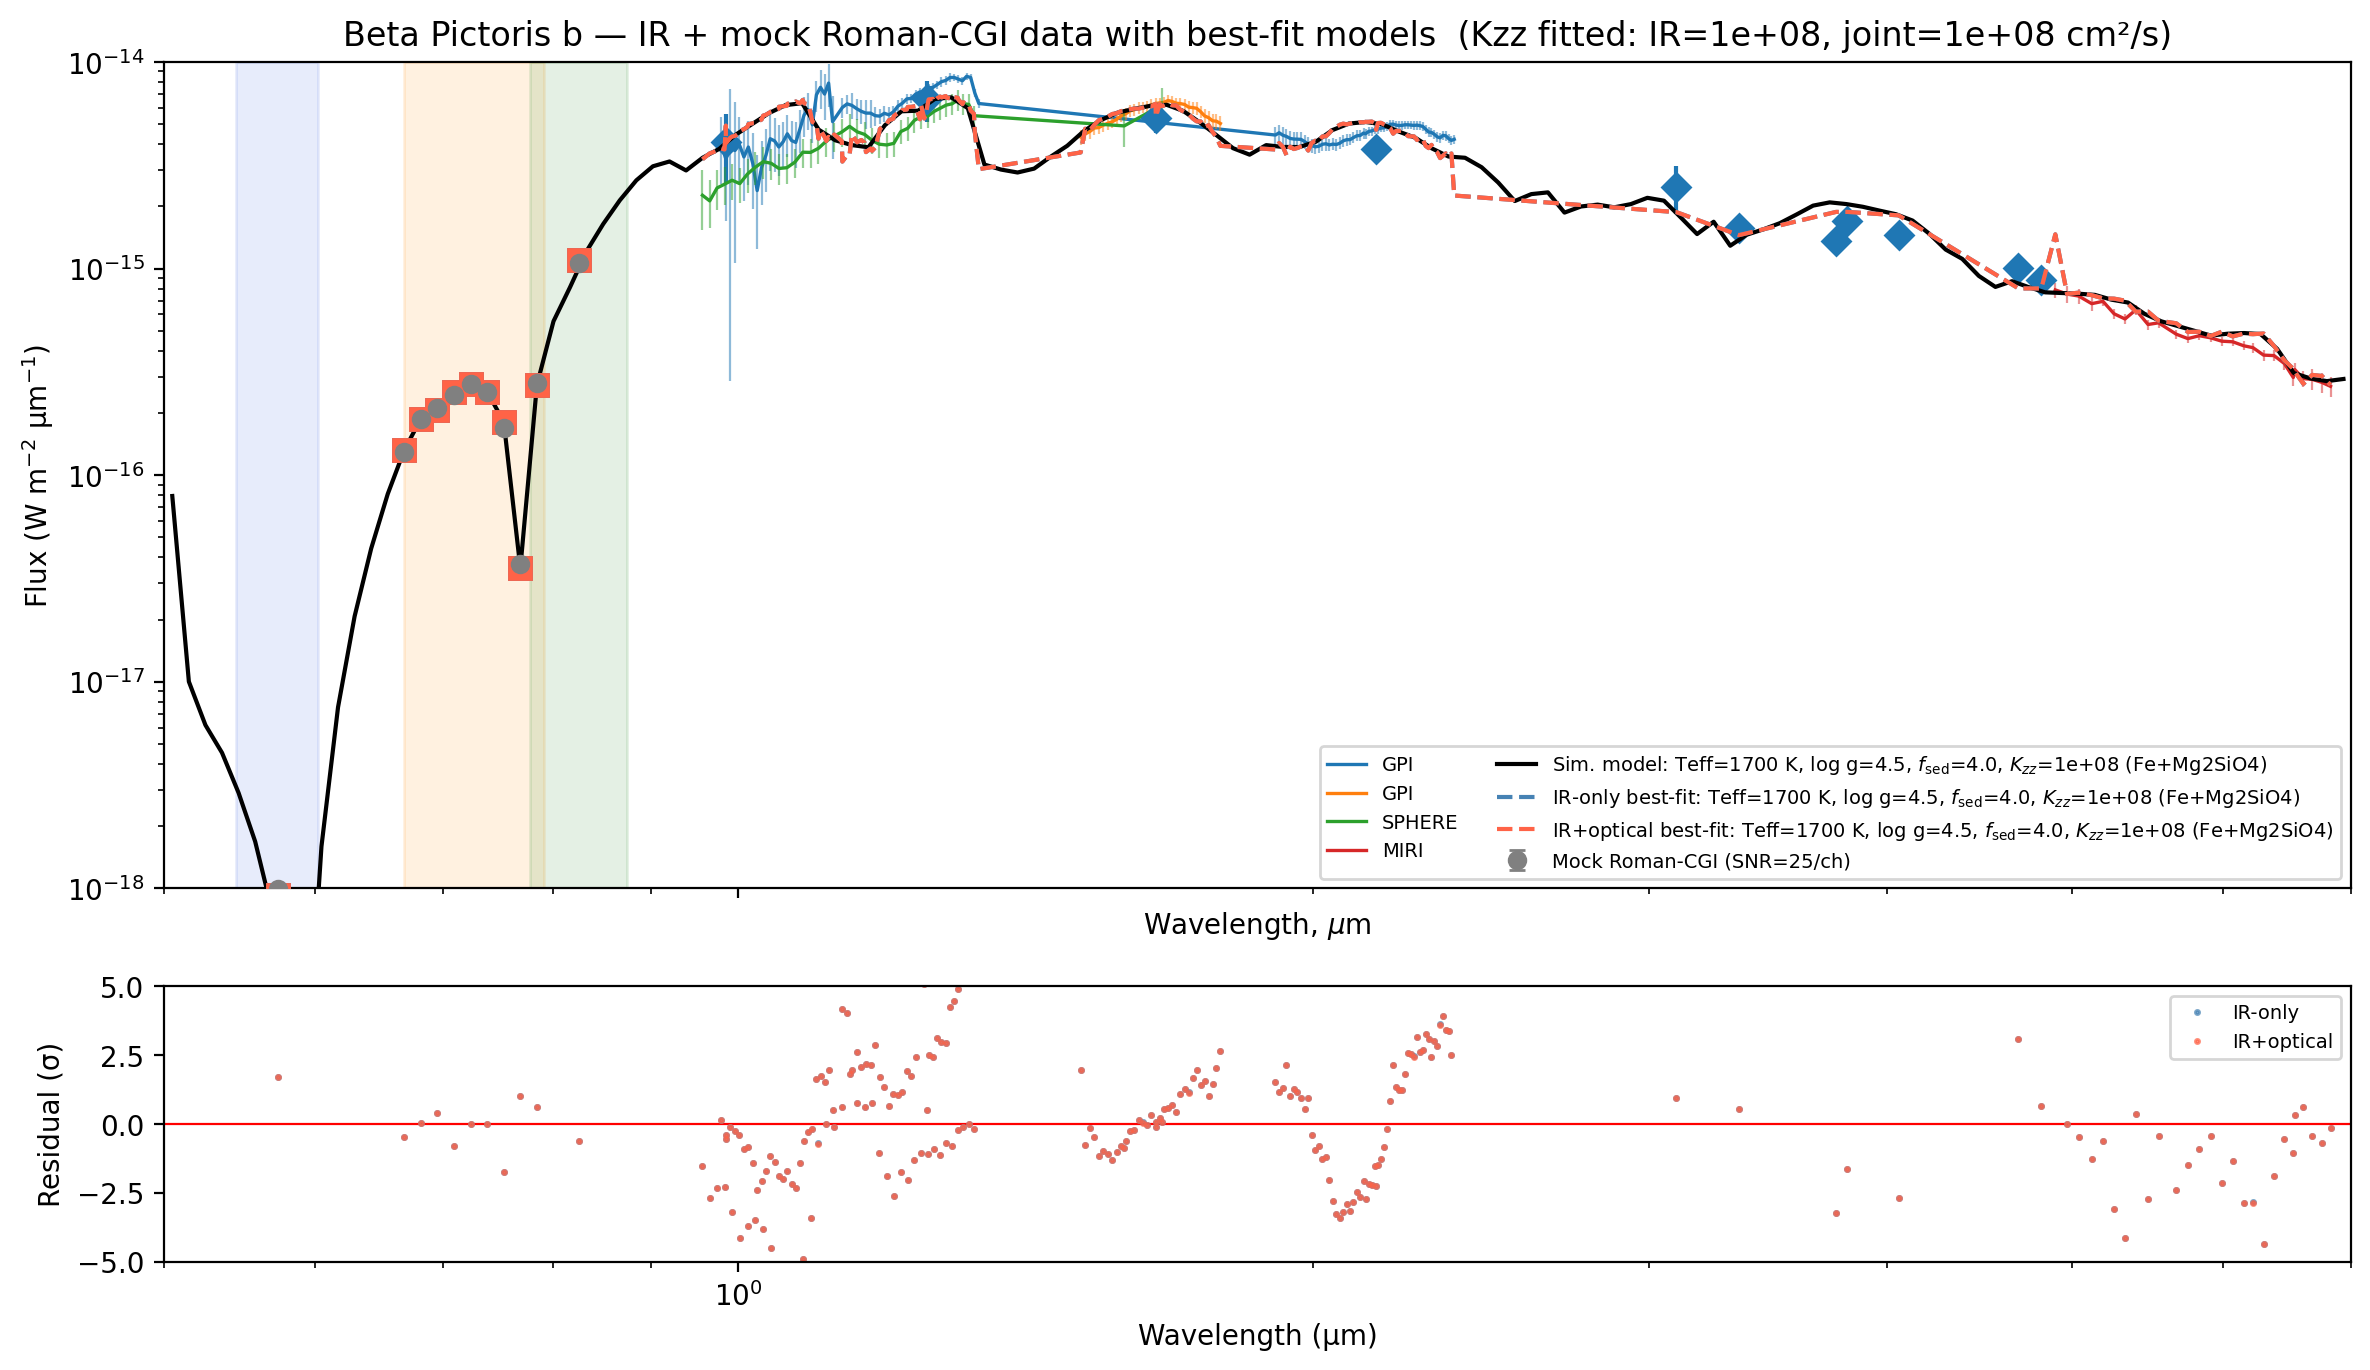

In [32]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True,
                         gridspec_kw={'height_ratios': [3, 1]})
ax, ax_res = axes

# ── IR observations colored by instrument ────────────────────────────────────
colors_inst = plt.cm.tab10.colors
for k, d in enumerate(plot_data):
    c = colors_inst[k % len(colors_inst)]
    is_phot_d = d['res'] == 0
    is_spec_d = ~is_phot_d
    kw = dict(color=c, label=d['ins'])
    if np.any(is_spec_d):
        ax.errorbar(d['wav'][is_spec_d], d['flx'][is_spec_d], d['err'][is_spec_d],
                    fmt='none', color=c, elinewidth=0.8, alpha=0.5)
        ax.plot(d['wav'][is_spec_d], d['flx'][is_spec_d], '-', **kw, lw=1.2)
        kw.pop('label')
    if np.any(is_phot_d):
        ax.errorbar(d['wav'][is_phot_d], d['flx'][is_phot_d], d['err'][is_phot_d],
                    fmt='D', ms=7, elinewidth=1.5, **kw)

# ── Mock Roman-CGI data ───────────────────────────────────────────────────────
ax.errorbar(wl_rcgi, flx_rcgi, yerr=err_rcgi, fmt='o', color='gray',
            ms=6, capsize=3, zorder=6, label=f'Mock Roman-CGI (SNR={SNR_RCGI}/ch)')

# ── Simulation truth model (used to generate the mock Roman-CGI data) ─────────
# fl_truth_scaled_R50 covers 0.5–7 µm at R=50, already multiplied by C_truth
sort_truth = np.argsort(1e4 / wno_truth_scaled_R50)
ax.plot((1e4 / wno_truth_scaled_R50)[sort_truth], fl_truth_scaled_R50[sort_truth],
        color='k', lw=1.5, zorder=4,
        label=(f'Sim. model: Teff={TEFF_LIT} K, log g={LOGG_LIT}, '
               f'$f_{{\\rm sed}}$={fsed_simdata}, $K_{{zz}}$={kzz_simdata:.0e} ({cloud_label_fixed})'))

# ── IR-only best-fit ──────────────────────────────────────────────────────────
# NIR part: sampled at observation wavelengths (grid_data layout: [:N_RCGI]=optical, [N_RCGI:]=NIR)
cloud_label_ir = 'Fe+Mg2SiO4' if best_clouds_active else 'clear'
ax.plot(wl_obs, C_best * best_model[N_RCGI:],
        color='steelblue', lw=1.5, ls='--', zorder=4,
        label=(f'IR-only best-fit: Teff={best_teff} K, log g={best_logg}, '
               f'$f_{{\\rm sed}}$={best_fsed}, $K_{{zz}}$={best_kzz:.0e} ({cloud_label_ir})'))
# Optical part: model values at Roman-CGI band wavelengths
ax.plot(wl_rcgi, C_best * best_model[:N_RCGI],
        's', color='steelblue', ms=8, zorder=5)

# ── IR+optical joint best-fit ─────────────────────────────────────────────────
cloud_label_joint = 'Fe+Mg2SiO4' if best_clouds_active_joint else 'clear'
ax.plot(wl_obs, C_best_joint * best_model_joint[N_RCGI:],
        color='tomato', lw=1.5, ls='--', zorder=4,
        label=(f'IR+optical best-fit: Teff={best_teff_joint} K, log g={best_logg_joint}, '
               f'$f_{{\\rm sed}}$={best_fsed_joint}, $K_{{zz}}$={best_kzz_joint:.0e} ({cloud_label_joint})'))
ax.plot(wl_rcgi, C_best_joint * best_model_joint[:N_RCGI],
        's', color='tomato', ms=8, zorder=5)

ax.set_yscale('log')
ax.set_xscale('log')
ax.legend(fontsize=7, ncol=2)
ax.set_title(f'Beta Pictoris b — IR + mock Roman-CGI data with best-fit models  '
             f'(Kzz fitted: IR={best_kzz:.0e}, joint={best_kzz_joint:.0e} cm²/s)')
rtu.format_roman_cgi_spectrum(ax, 1e-18, 1e-14, xlim=(0.5, 7),
                               ylabel='Flux (W m$^{-2}$ µm$^{-1}$)')

# ── Residuals vs IR data ──────────────────────────────────────────────────────
resid_ir    = (full_flx_obs - C_best       * best_model) / full_err_obs
resid_joint = (full_flx_obs - C_best_joint * best_model_joint) / full_err_obs
ax_res.axhline(0, color='r', lw=0.8)
ax_res.plot(full_wl_obs, resid_ir,    '.', color='steelblue', ms=3, alpha=0.7, label='IR-only')
ax_res.plot(full_wl_obs, resid_joint, '.', color='tomato',    ms=3, alpha=0.7, label='IR+optical')
ax_res.set_ylabel('Residual (σ)')
ax_res.set_xlabel('Wavelength (µm)')
ax_res.set_ylim(-5, 5)
ax_res.legend(fontsize=7)
plt.tight_layout()
plt.show()

Ideas for further exploration:

- Quick: adjust SNR for mock Roman-CGI data, what happens?
- Quick: recompute chi2 loop with subsets of Roman-CGI coverage.
- Quick: try drawing a different realization within the error bars of the IR data, and repeating excercise of fitting with and without Roman-CGI
- Slower: pick one of the other targets from the ewi database and carry out a similar study.